# Analisi moltean/fruits datset
Questo notebook viene creato per analizzare il dataset utilizzato, controlleremo e mostreremo le varie immagini.

PS: I file *analyzer.py* e *balncer.py* fanno questo lavoro automaticamente, andando a creare ulteriori immagini in caso di sbilanciamento

In [25]:
# Import necessari

import os
import re
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset

## Controllo classi

### Numero di classi
Dal dataset utilizzato per il training otteniamo il numero di classi.

*PS*: Per via di come il creatore del dataset ha gestito le immagini/cartelle bisogna lavorare un pochino per evitare duplicati...aggiungo anche che alcune classi più specifiche verranno raggruppate (ES: mele).

In [26]:
# Percorso del dataset di training
data_dir = 'dataset/fruits-360_dataset_original-size/fruits-360-original-size/Training'

# Otteniamo le classi
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
num_classes = len(classes)
print(f'Num of classes: {num_classes}')

Num of classes: 24


### Numero di immagini per ogni classe
Ora controlliamo quante immagini sono presenti per ogni classe

In [27]:
# Calcoliamo il numero di immagini per classe
class_counts = {}
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if 'balImg_' not in f] # escludiamo le immagini create dal balancer
    class_counts[class_name] = len(image_files)
    print(f'{class_name}: {len(image_files)}')

apple_6: 315
apple_braeburn_1: 320
apple_crimson_snow_1: 318
apple_golden_1: 308
apple_golden_2: 308
apple_golden_3: 316
apple_granny_smith_1: 320
apple_hit_1: 468
apple_pink_lady_1: 313
apple_red_1: 309
apple_red_2: 318
apple_red_3: 281
apple_red_delicios_1: 300
apple_red_yellow_1: 308
apple_rotten_1: 319
cabbage_white_1: 96
carrot_1: 101
cucumber_1: 100
cucumber_3: 163
eggplant_long_1: 160
pear_1: 326
pear_3: 144
zucchini_1: 160
zucchini_dark_1: 160


### Distribuzione delle classi

Tramite la libreria **matplot** mostriamo tramite grafico la distribuzione delle classi

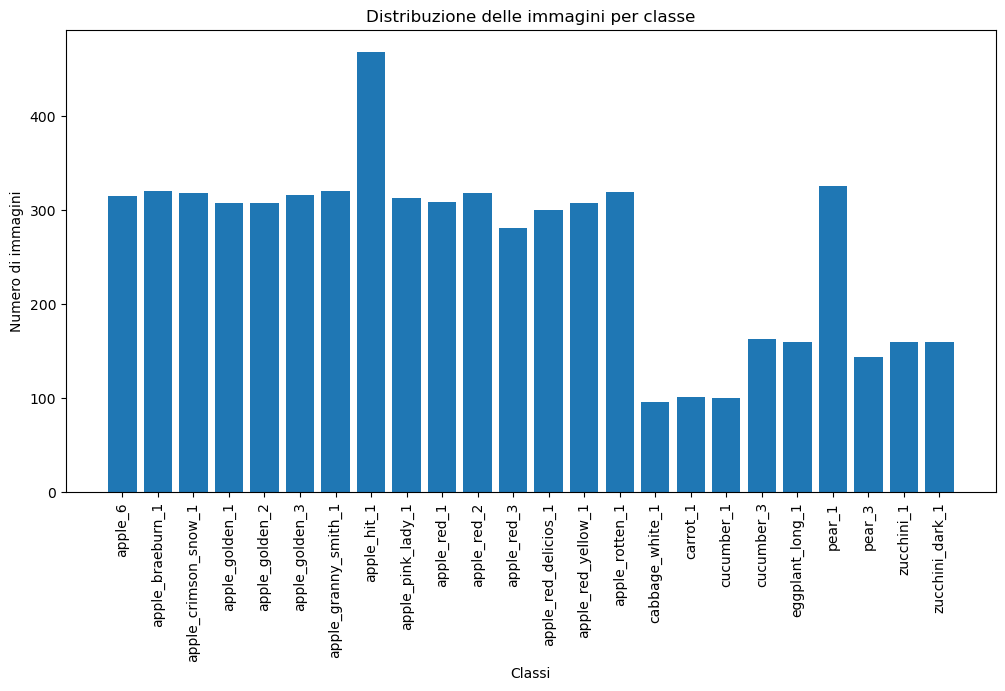

In [28]:
# Creiamo un grafico a barre per visualizzare la distribuzione delle immagini per classe
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.xlabel('Classi')
plt.ylabel('Numero di immagini')
plt.title('Distribuzione delle immagini per classe')
plt.show()

## Visualizzazione immagini

Di seguito alcuni esempi delle immagini che il dataset fornisce...

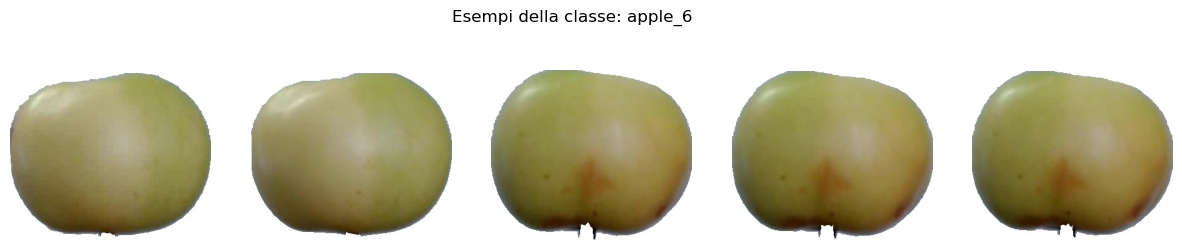

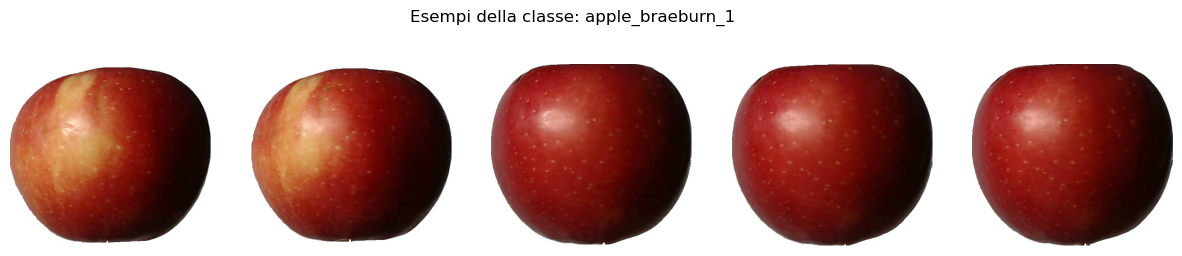

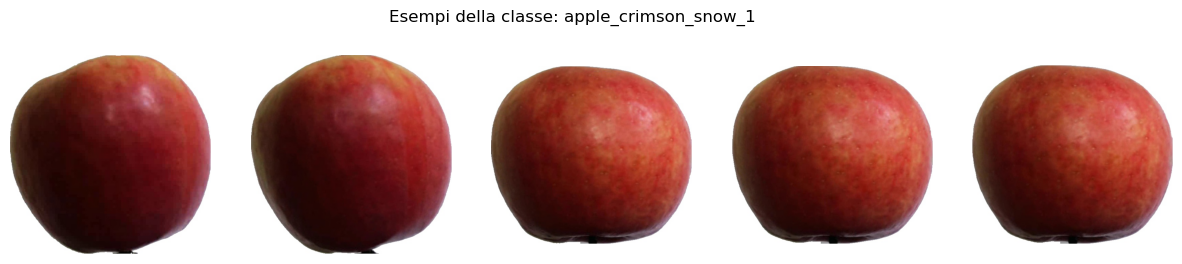

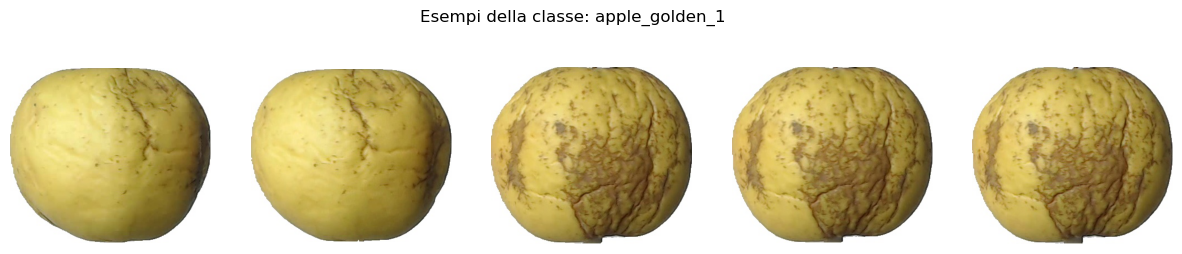

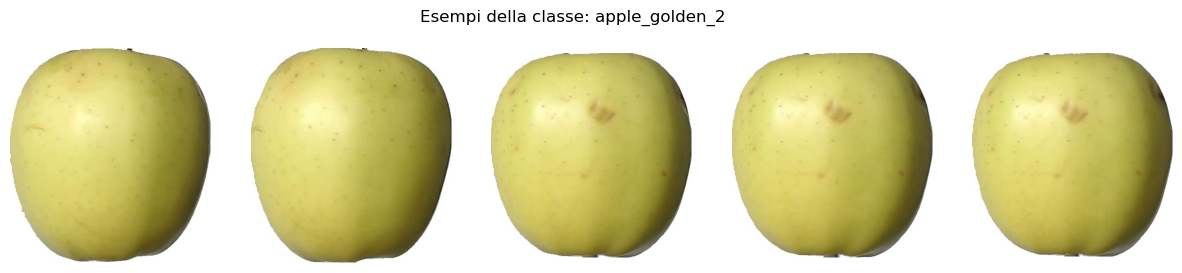

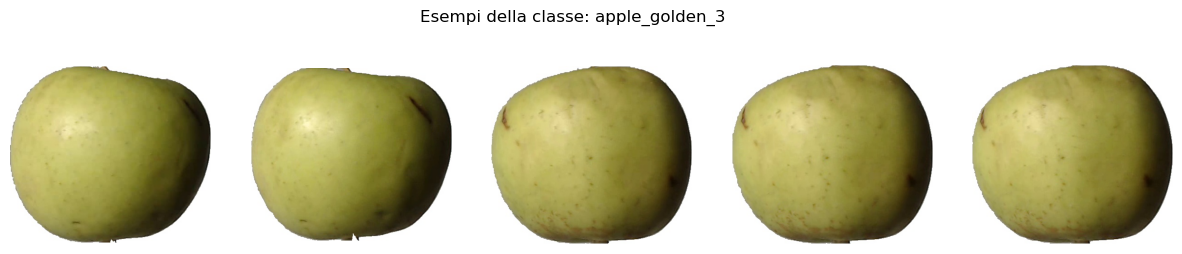

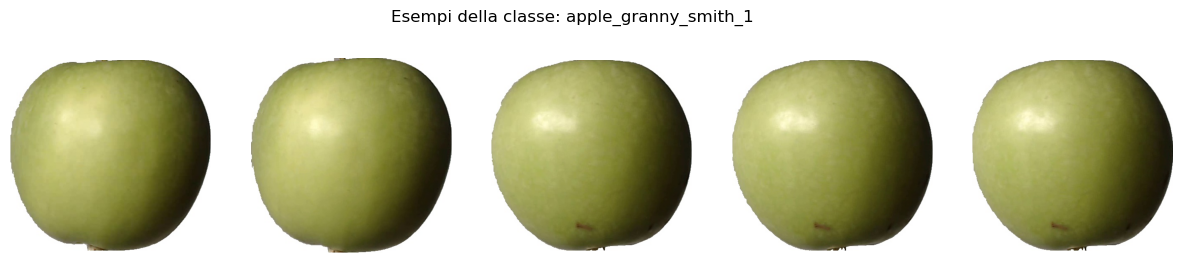

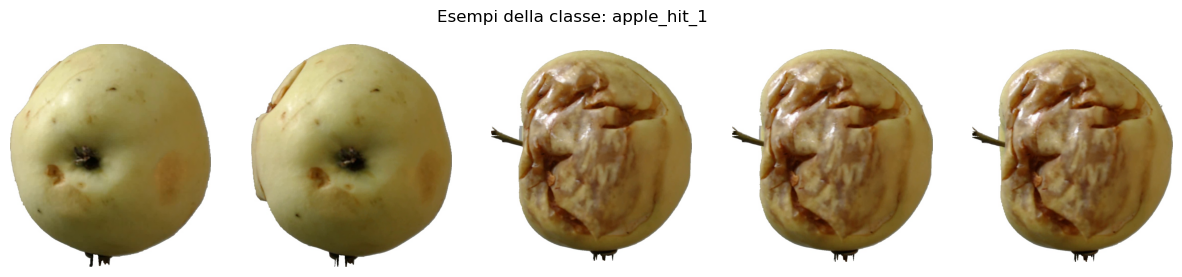

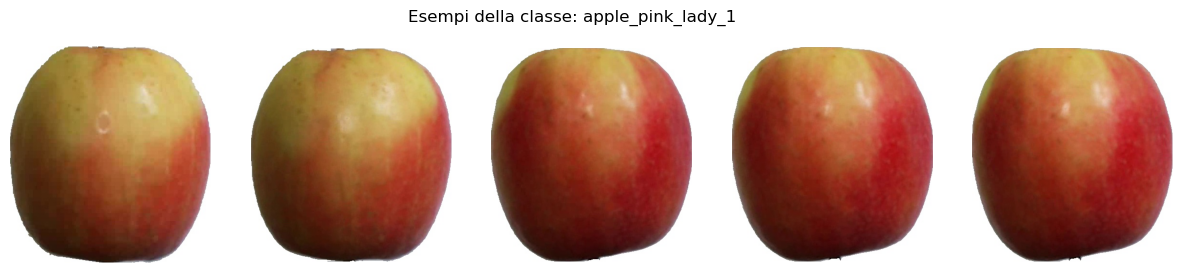

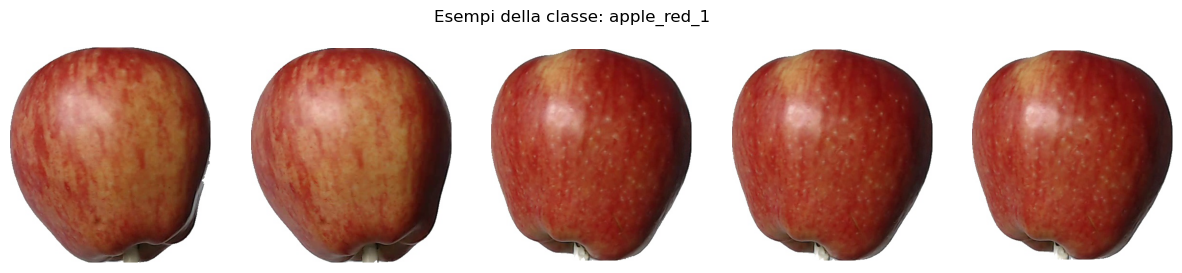

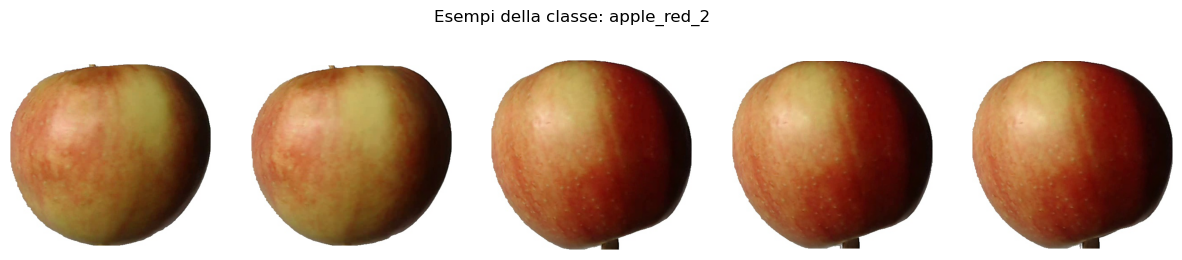

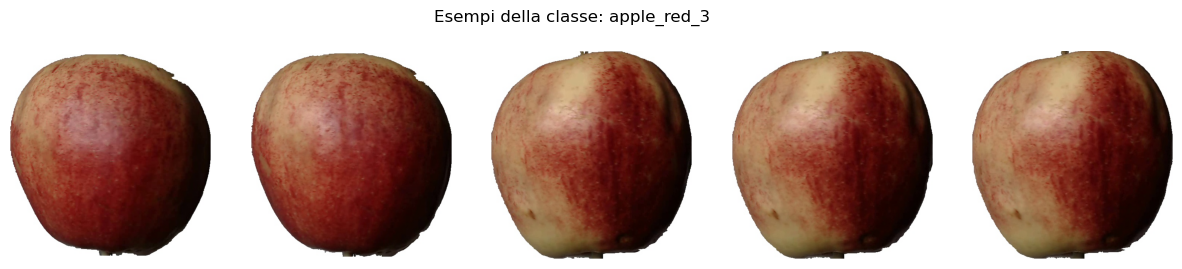

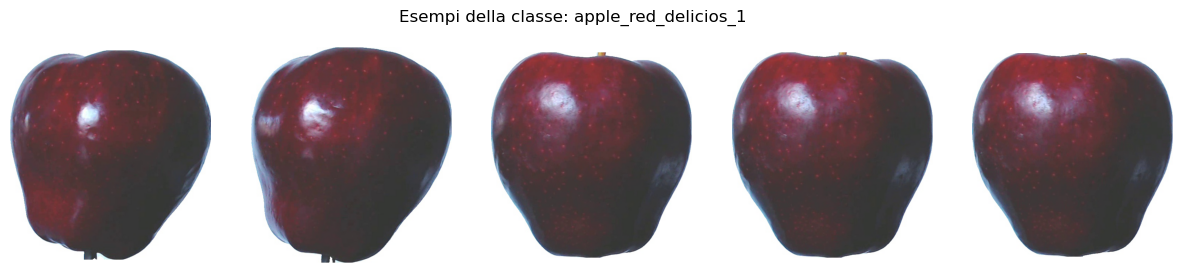

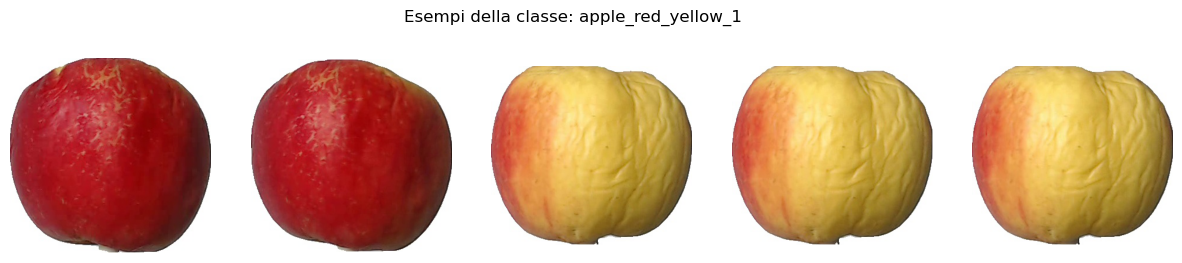

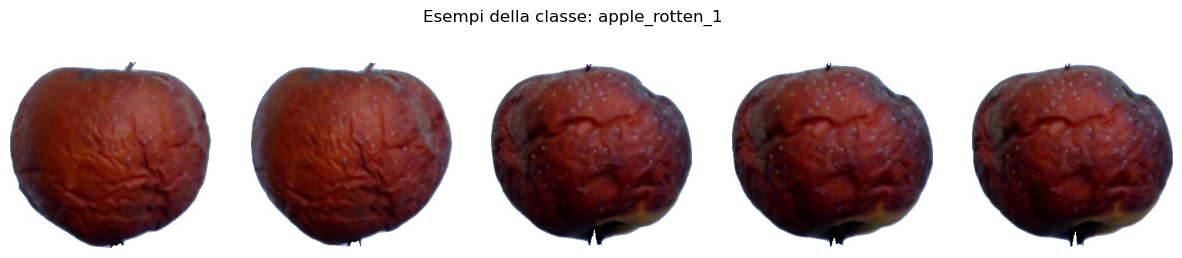

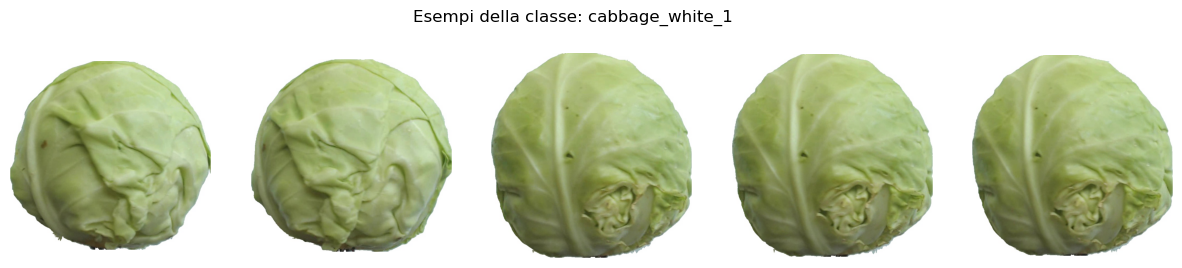

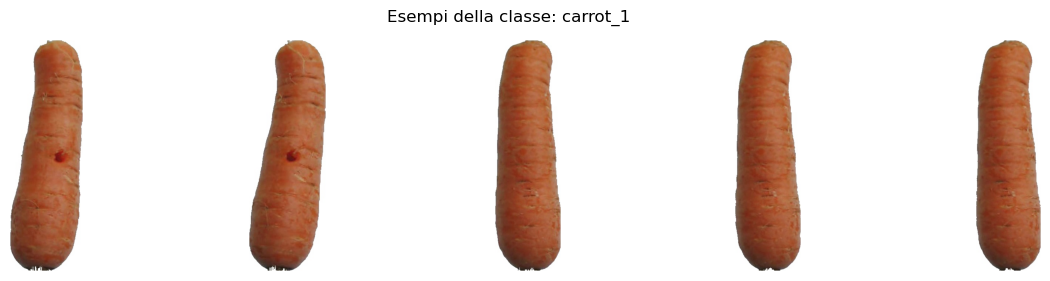

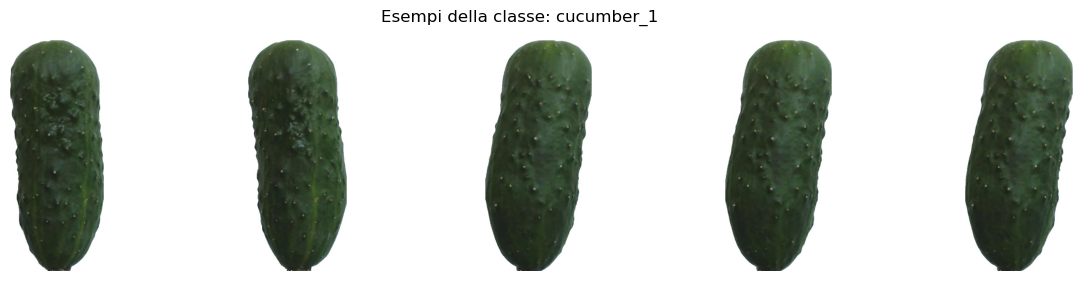

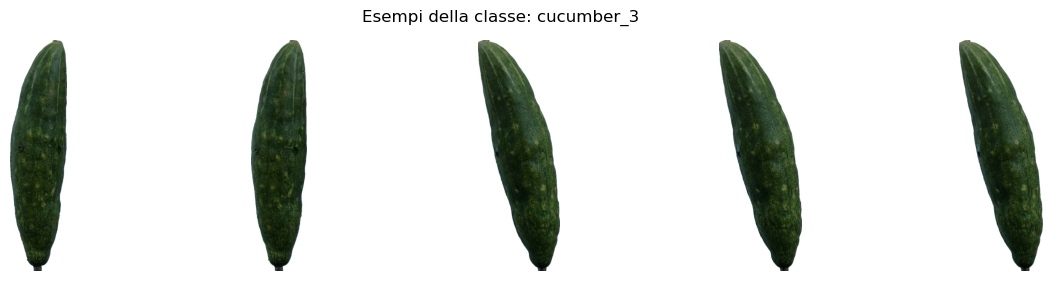

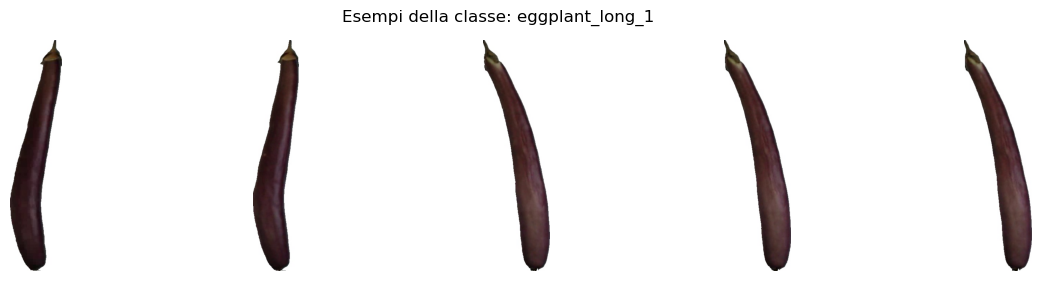

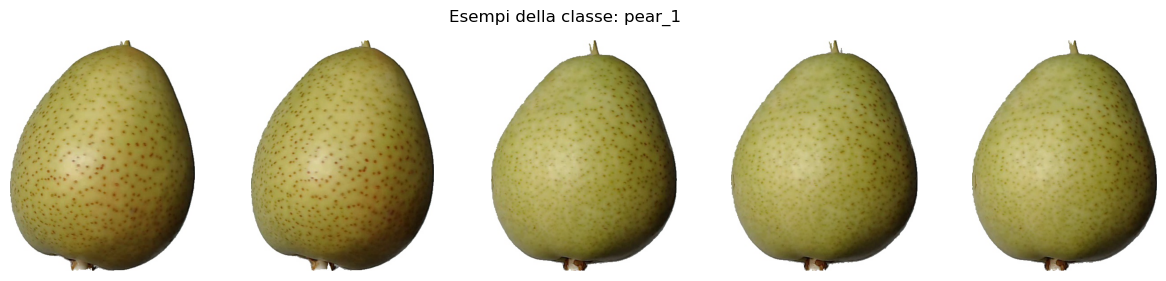

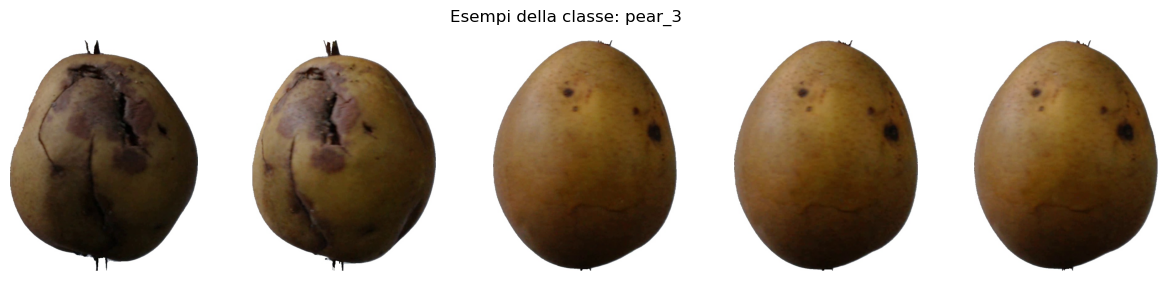

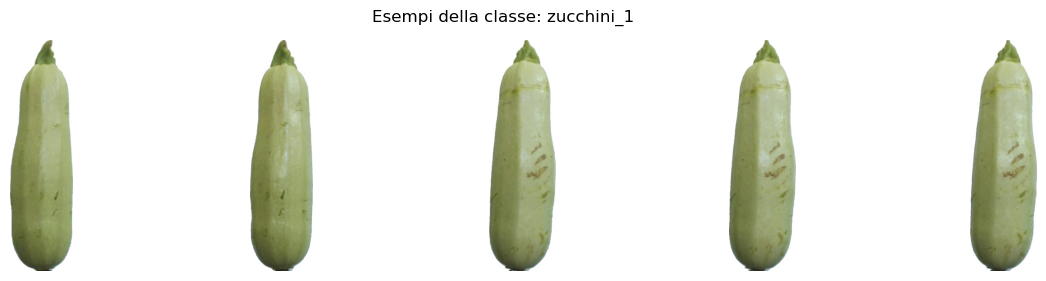

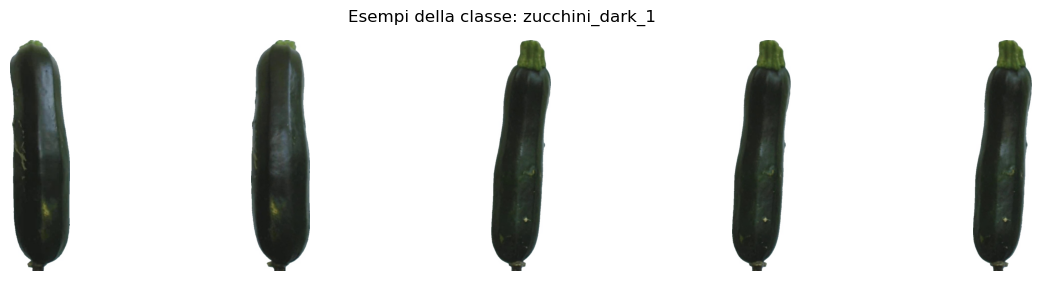

In [29]:
# Mostriamo alcune immagini di esempio per ogni classe
N = 5  # Numero di immagini da visualizzare per classe
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if 'balImg_' not in f][:N] # come prima escludiamo le immagini create dal balancer
    
    plt.figure(figsize=(15, 3))
    for i, image_name in enumerate(image_files):
        img_path = os.path.join(class_path, image_name)
        img = Image.open(img_path)
        plt.subplot(1, N, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f'Esempi della classe: {class_name}')
    plt.show()